In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import pickle
from tqdm.auto import tqdm

EXAMPLE = 'groceriesworld'

data_dir = f'examples/{EXAMPLE}/data_dir_gw/'

datapoint_files = sorted(glob.glob(f'{data_dir}*.pkl'))
datapoints = []
for dp_file in tqdm(datapoint_files):
    with open(dp_file, 'rb') as f:
        datapoints.append(pickle.load(f))

  0%|          | 0/271 [00:00<?, ?it/s]

In [3]:
from semantic_state_estimator.semantic_state_estimator import SemanticStateEstimatorWithLLaMA

import warnings
warnings.filterwarnings("ignore")

LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"
LLAVA_ID = "lmms-lab/llava-onevision-qwen2-7b-ov"

se = SemanticStateEstimatorWithLLaMA(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id=LLAVA_ID
)

/home/gazran/miniforge3/envs/my_sse/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


predicate queries loaded from cache
Loaded LLaVA model: lmms-lab/llava-onevision-qwen2-7b-ov


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
You are using a model of type llava to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Loading vision tower: google/siglip-so400m-patch14-384


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model Class: LlavaQwenForCausalLM


In [4]:

from semantic_state_estimator.utils.up_utils import get_all_grounded_predicates_for_objects

ground_literals = get_all_grounded_predicates_for_objects(se.up_problem)
lit_map = {str(lit): i for i, lit in enumerate(ground_literals)}



In [5]:
from semantic_state_estimator.eval.process_datapoints import *
dp = datapoints[0]

set_dp_true_state_arr(dp, lit_map)
set_dp_est_state_arr(dp, se, lit_map, seed=None)

  0%|          | 0/25 [00:00<?, ?it/s]

In [6]:
dp[ESTIMATED_STATE_ARR_PROB_KEY]

{None: array([0.91180992, 0.18476751, 0.09268778, 0.10521053, 0.99620521,
        0.85966372, 0.96239138, 0.8879841 , 0.9871788 , 0.12002562,
        0.57940048, 0.07978202, 0.96789932, 0.54673815, 0.63883531,
        0.98813087, 0.4073334 , 0.57940042, 0.93146253, 0.01566365,
        0.00674499, 0.02887091, 0.00163568, 0.08570928, 0.05184547])}

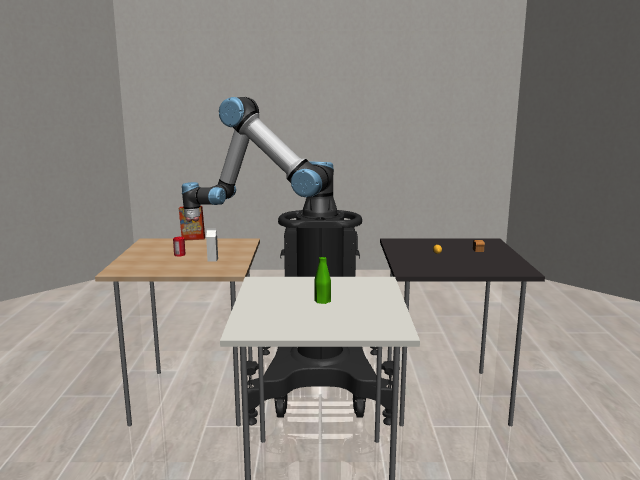

In [19]:
from PIL import Image

Image.fromarray(dp['renders']['frontview'])

In [15]:
(dp[ESTIMATED_STATE_ARR_PROB_KEY][None] >= 0.9).astype(float)

array([1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 0., 0., 0.])

In [13]:
dp[TRUE_STATE_ARR_KEY]

array([1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0.])

In [16]:
lit_map

{'on-table(milk-carton,wood-table)': 0,
 'on-table(milk-carton,black-table)': 1,
 'on-table(milk-carton,white-table)': 2,
 'on-table(lemon,wood-table)': 3,
 'on-table(lemon,black-table)': 4,
 'on-table(lemon,white-table)': 5,
 'on-table(green-bottle,wood-table)': 6,
 'on-table(green-bottle,black-table)': 7,
 'on-table(green-bottle,white-table)': 8,
 'on-table(loaf-of-bread,wood-table)': 9,
 'on-table(loaf-of-bread,black-table)': 10,
 'on-table(loaf-of-bread,white-table)': 11,
 'on-table(red-box-of-cereal,wood-table)': 12,
 'on-table(red-box-of-cereal,black-table)': 13,
 'on-table(red-box-of-cereal,white-table)': 14,
 'on-table(red-can-of-soda,wood-table)': 15,
 'on-table(red-can-of-soda,black-table)': 16,
 'on-table(red-can-of-soda,white-table)': 17,
 'robot-gripper-empty()': 18,
 'robot-gripping(milk-carton)': 19,
 'robot-gripping(lemon)': 20,
 'robot-gripping(green-bottle)': 21,
 'robot-gripping(loaf-of-bread)': 22,
 'robot-gripping(red-box-of-cereal)': 23,
 'robot-gripping(red-can-o

In [ ]:
from aidm.environments.pddl.pddl_env import PDDLProblem

def lit_to_str(lit):
    return f'{lit.predicate.name}({",".join(map(lambda var: var.name, lit.variables))})'

problem = se.up_problem
ground_literals = problem.env.observation_space.all_ground_literals(problem.env.get_state())
lit_to_idx = {lit_to_str(lit): i for i, lit in enumerate(ground_literals)}
num_lits = len(ground_literals)

In [ ]:
import numpy as np
from tqdm.auto import tqdm
import pickle


def set_dp_true_state_arr(dp):
    ts = dp['true_state']
    ts_arr = np.zeros(num_lits)
    for lit in ts.literals:
        ts_arr[lit_to_idx[lit_to_str(lit)]] = 1
    dp['true_state_array'] = ts_arr

def set_all_dp_true_state_arrs(datapoints):
    for dp in tqdm(datapoints):
        set_dp_true_state_arr(dp)

set_all_dp_true_state_arrs(datapoints)

In [ ]:
se.vqa_model.clear_system_cache()

In [ ]:
se.vqa_model.system_cache

In [ ]:
from PIL import Image

CONFIDENCE = 0.5

def predict_dp_state(dp, se):
    imgs = [Image.fromarray(img) for img in dp['renders'].values()]
    prob_map = se.estimate_state(imgs[1:2])
    return prob_map

def set_dp_est_state_arr(dp, se):
    prob_map = predict_dp_state(dp, se)
    
    es_array = np.zeros(num_lits)
    for lit_str in prob_map:
        if lit_str not in lit_to_idx:
            continue
        es_array[lit_to_idx[lit_str]] = prob_map[lit_str]

    dp['est_state_array_prob'] = es_array
    dp['est_state_array'] = (es_array > CONFIDENCE).astype(float)

def set_all_dp_est_state_arr(datapoints, se):
    for dp in tqdm(datapoints):
        if 'est_state_array' in dp:
            continue
        set_dp_est_state_arr(dp, se)

set_all_dp_est_state_arr(datapoints, se)

In [ ]:
from PIL import Image

dp = datapoints[0]

imgs = [
    Image.fromarray(img) for img in dp['renders'].values()
]

prob_map = se.estimate_state([imgs[0]])

In [ ]:
imgs[0]

In [ ]:
prob_map

In [ ]:
CONFIDENCE = 0.5

es_array = np.zeros(num_lits)
for lit_str in prob_map:
    if lit_str not in lit_to_idx:
        continue
    es_array[lit_to_idx[lit_str]] = prob_map[lit_str]
dp['est_state_array_prob'] = es_array
dp['est_state_array'] = (es_array > CONFIDENCE).astype(float)

In [ ]:
for i in range(1000):
    if 'est_state_array' not in datapoints[i]:
        break

In [ ]:
def hamming_distance(a, b):
    return np.count_nonzero(a != b)

def normalized_hamming_distance(a, b):
    return hamming_distance(a, b) / len(b)

def batch_normalized_hamming_distance(a_batch, b_batch):
    d_batch = []
    for a, b in zip(a_batch, b_batch):
        d_batch.append(normalized_hamming_distance(a, b))
    return np.mean(d_batch)

def tp_fp_tn_fn(a, b):
    tp = (a == 1) & (b == 1)
    fp = (a == 0) & (b == 1) 
    tn = (a == 0) & (b == 0)
    fn = (a == 1) & (b == 0)
    return tp.sum(), fp.sum(), tn.sum(), fn.sum()

def batch_tp_fp_tn_fn(a_batch, b_batch):
    tp_total = fp_total = tn_total = fn_total = 0
    for a, b in zip(a_batch, b_batch):
        tp, fp, tn, fn = tp_fp_tn_fn(a, b)
        tp_total += tp
        fp_total += fp
        tn_total += tn
        fn_total += fn
    return tp_total, fp_total, tn_total, fn_total

def f_beta(beta, tp, fp , fn):
    tp_term = ((1 + beta**2) * tp)
    return tp_term / (tp_term + (beta**2)*fn + fp) 

def batch_metrics_with_confidence(a_batch, b_batch, conf_range):
    out = {}
    for c in conf_range:
        cur_b_batch = (b_batch >= c).astype(float)
        tp, fp, tn, fn = batch_tp_fp_tn_fn(a_batch, cur_b_batch)
        total = tp + fp + tn + fn
        out[c] = {
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn,
            'tpr': tp / (tp + fn),
            'fpr': fp / (fp + tn),
            'acc': (tp + tn) / total,
            'precision': tp / (tp + fp),
            'recall': tp / (tp + fn),
            'f1': f_beta(1, tp, fp, fn),
            'f2': f_beta(2, tp, fp, fn)
        }
    return out

# batch_normalized_hamming_distance(map(lambda x: x['true_state_array'], datapoints[:116]), map(lambda x: x['est_state_array'], datapoints[:116]))
# tp, fp, tn, fn = batch_tp_fp_tn_fn(map(lambda x: x['true_state_array'], datapoints[:116]), map(lambda x: x['est_state_array'], datapoints[:116]))
out = batch_metrics_with_confidence(np.array(list(map(lambda x: x['true_state_array'], datapoints))),
                                    np.array(list(map(lambda x: x['est_state_array_prob'], datapoints))),
                                    np.linspace(0, 1, num=11))
out[0.5]

In [ ]:
import matplotlib.pyplot as plt
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['acc'], out.values())), label='acc')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['precision'], out.values())), label='precision')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['recall'], out.values())), label='recall')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['f1'], out.values())), label='f1')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['f2'], out.values())), label='f2')
plt.plot(list(map(lambda x: x['fpr'], out.values())) + [0], list(map(lambda x: x['tpr'], out.values())) + [0], label='ROC')
plt.legend()

In [ ]:
plt.title('Accuracy by confidence')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['acc'], out.values())))
plt.xlabel('confidence threshold for positive prediction')
plt.ylabel('prediction accuracy (all classes)')
plt.grid()
plt.show()

In [ ]:
plt.title('precision by confidence')
plt.ylim((0, 1))
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['precision'], out.values())))
plt.xlabel('confidence threshold for positive prediction')
plt.ylabel('prediction precision (all classes)')
plt.grid()
plt.show()

In [ ]:
plt.title('Recall by confidence')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['recall'], out.values())))
plt.xlabel('confidence threshold for positive prediction')
plt.ylabel('prediction recall (all classes)')
plt.grid()
plt.show()

In [ ]:
plt.title('ROC curve')
plt.plot(list(map(lambda x: x['fpr'], out.values())) + [0], list(map(lambda x: x['tpr'], out.values())) + [0])
plt.plot(np.linspace(0, 1, num=11), np.linspace(0, 1, num=11), color='gray', linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.grid()
plt.show()

In [ ]:
fpr = [out[c]['fp']]

plt.plot()

In [ ]:
with open(datapoints[0], 'rb') as f:
    dp = pickle.load(f)

imgs = [
    Image.fromarray(img) for img in dp['renders'].values()
]


imgs[0]

In [ ]:
se.queries_dict

In [ ]:
prob_map